In [25]:
from matplotlib.gridspec import GridSpec
import networkx as nx
from itertools import product
from collections import defaultdict
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import circmean
from scipy.stats import circstd
from pathlib import Path
import sys
import numpy as np
import glob
import os
from scipy.stats import iqr
from scipy.ndimage import gaussian_filter


%load_ext autoreload
%autoreload

def get_parent_dir():
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)

sys.path.append(parent_dir)
from stimulus_experiments.entrainment_experiments import *
from stimulus_experiments.entrainment_analysis import *
from stimulus_experiments.main_entrain import (
    parse_args,
    build_train_config,
    build_baseline_config,
    build_test_config,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent directory: c:\Users\HP\ModellingProjects\Olivocerebellar-circuit


## Overview run functions/contrasts

### Training:
o Fixed stimulus interval for training
o Variable stimulus interval for training
o No stimulus training / convergence

Training runs are short, should not need to be split.
ISI's to use for training:
- 120ms (flocculus) mean 
- 35ms for std, when variables ISI

### Testing:
o Fixed different mean ISI, fixed ISI trained, plastic model

o Fixed different mean ISI, fixed ISI trained, static model

o Fixed different mean ISI, variable ISI trained, plastic model

o Fixed different mean ISI, variable ISI trained, static model

o Fixed different mean ISI, no stimulus trained, plastic model

o Fixed different mean ISI, no stimulus trained, static model


#### Controls for test runs:
o Fixed same mean ISI, fixed ISI trained, static model

o No stimulus, fixed ISI trained, plastic model

o No stimulus, variable ISI trained, plastic model

### Baseline 
o Plastic model, no input

o Plastic model, fixed mean ISI

o Plastic model, variable mean ISI



## Command generators


### Training runs

In [22]:
jobs_fixed_isi = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                                 ISI_values=None, experiment="fixed-isi", ISI_std=0.0, tag=None)
jobs_variable_isi = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                                    ISI_values=None, experiment="variable-isi", ISI_std=35.0, tag=None)
jobs_nostim = train_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=80_000,
                              ISI_values=None, experiment="nostim", ISI_std=0.0, tag=None)

In [23]:
# Fixed isi commands
for job in jobs_fixed_isi:
    print(job["command"])


python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment fixed-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-mean 120.0 --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment f

In [24]:
# Variable isi commands
for job in jobs_variable_isi:
    print(job["command"])

python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 35.0
python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 35.0
python3 main_entrain.py --run-type train --experiment variable-isi --PFPC_plasticity-on True --OU-stim-io-on True --OU-stim-pf-on True --OU-stim-isi-std 35.0 --OU-stim-isi-mean 120.0 --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir /home/izet/Olivocerebellar-circuit --OU-stim-isi-mean 120

In [6]:
# Nostim commands
for job in jobs_nostim: 
    print(job["command"])

python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 88 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir c:\Users\HP\ModellingProjects\Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 89 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir c:\Users\HP\ModellingProjects\Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 90 --monitor-preset "stimulus_testing" --simdur 80000.0 --parent-dir c:\Users\HP\ModellingProjects\Olivocerebellar-circuit --OU-stim-isi-mean 120.0 --OU-stim-isi-std 0.0
python3 main_entrain.py --run-type train --experiment nostim --PFPC_plastici

### Baseline runs

In [ ]:
## Baseline run with stimulus + fixed isi
jobs_fixed_isi_bas = baseline_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=20_000,
                                 ISI_values=None, experiment="fixed-isi", ISI_std=0.0, tag=None)
jobs_variable_isi_bas= baseline_commands(parent_dir, monitor= "stimulus_testing", n_seeds=20, simdur=20_000,
                                 ISI_values=None, experiment="variable-isi", ISI_std=35.0, tag=None)

In [ ]:
## Baseline runs without input
# Get commands and paths for all baseline runs
base_repl_jobs = baseline_commands(parent_dir = parent_dir, n_seeds=10, simdur= 30_000.0)
for job in base_repl_jobs:
    print(job["command"])




python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 88 --monitor-preset "plasticity_min" --simdur 30000.0 --parent-dir /home/izet/Olivocerebellar-circuit --timestamp "07-29_10;59;21" --timestep 0.5 --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 89 --monitor-preset "plasticity_min" --simdur 30000.0 --parent-dir /home/izet/Olivocerebellar-circuit --timestamp "07-29_10;59;21" --timestep 0.5 --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True --OU-stim-io-on False --OU-stim-pf-on False --seed 90 --monitor-preset "plasticity_min" --simdur 30000.0 --parent-dir /home/izet/Olivocerebellar-circuit --timestamp "07-29_10;59;21" --timestep 0.5 --downsample 80
python3 main_entrain.py --run-type baseline --experiment nostim --PFPC_plasticity-on True -

### Testing runs

## Analysis & plots

### Stimulus check

In [ ]:

fixed_isi_baseline_paths = [job["run_path"] for job in jobs_fixed_isi]

fixed_isi_paths = [job["run_path"] for job in jobs_variable_isi]

# load 1 dataset
with np.load(fixed_isi_paths[0], allow_pickle=True) as npz:
    data = {k: npz[k] for k in npz.files}

print("Data keys:", data.keys())
pf_start = np.int64(data["stim_pf_start"][0])
io_start = np.int64(data["stim_io_start"][0])

print("OU PF range:", np.min(data["pf.I_OU"][0:pf_start, :]), np.max(data["pf.I_OU"][0:pf_start, :]))
print("OU PF mean:", np.mean(data["pf.I_OU"][0:pf_start, :]), "OU PF median:", np.median(data["pf.I_OU"][0:pf_start, :]))

print("OU IO range:", np.min(data["io.I_OU"][0:io_start, :]), np.max(data["io.I_OU"][0:io_start, :]))
print("OU IO mean:", np.mean(data["io.I_OU"][0:io_start, :]), "OU IO median:", np.median(data["io.I_OU"][0:io_start, :]))

print(data["pf.I_OU"].shape, data["io.I_OU"].shape)

io_spk_idx = np.where(data["io.spike"])[0]
print(data["ts"][io_spk_idx])

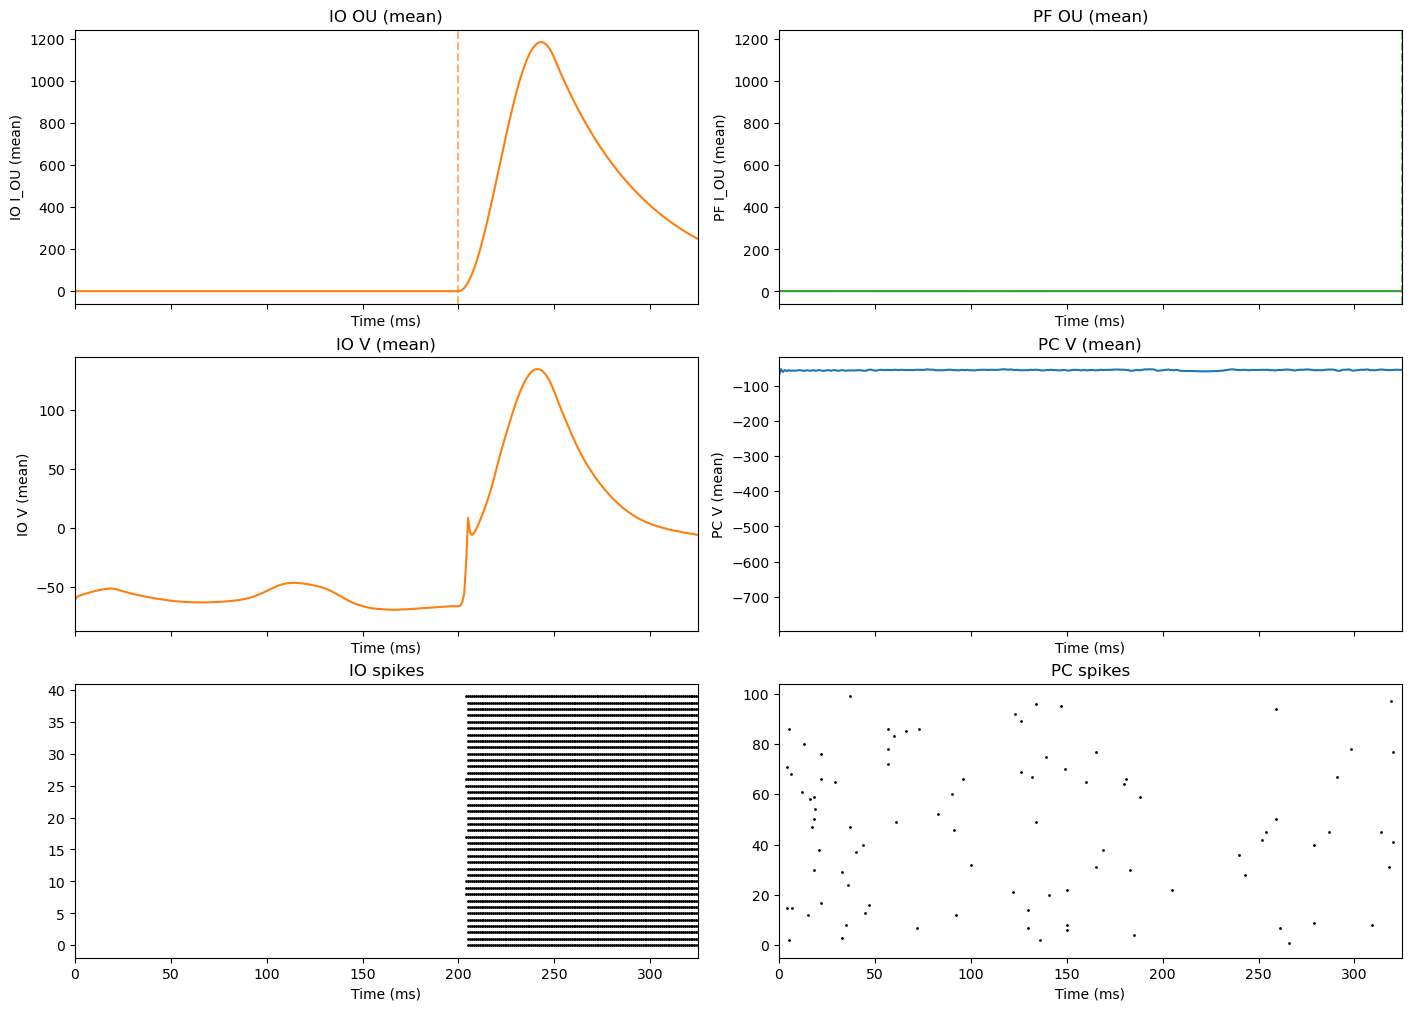

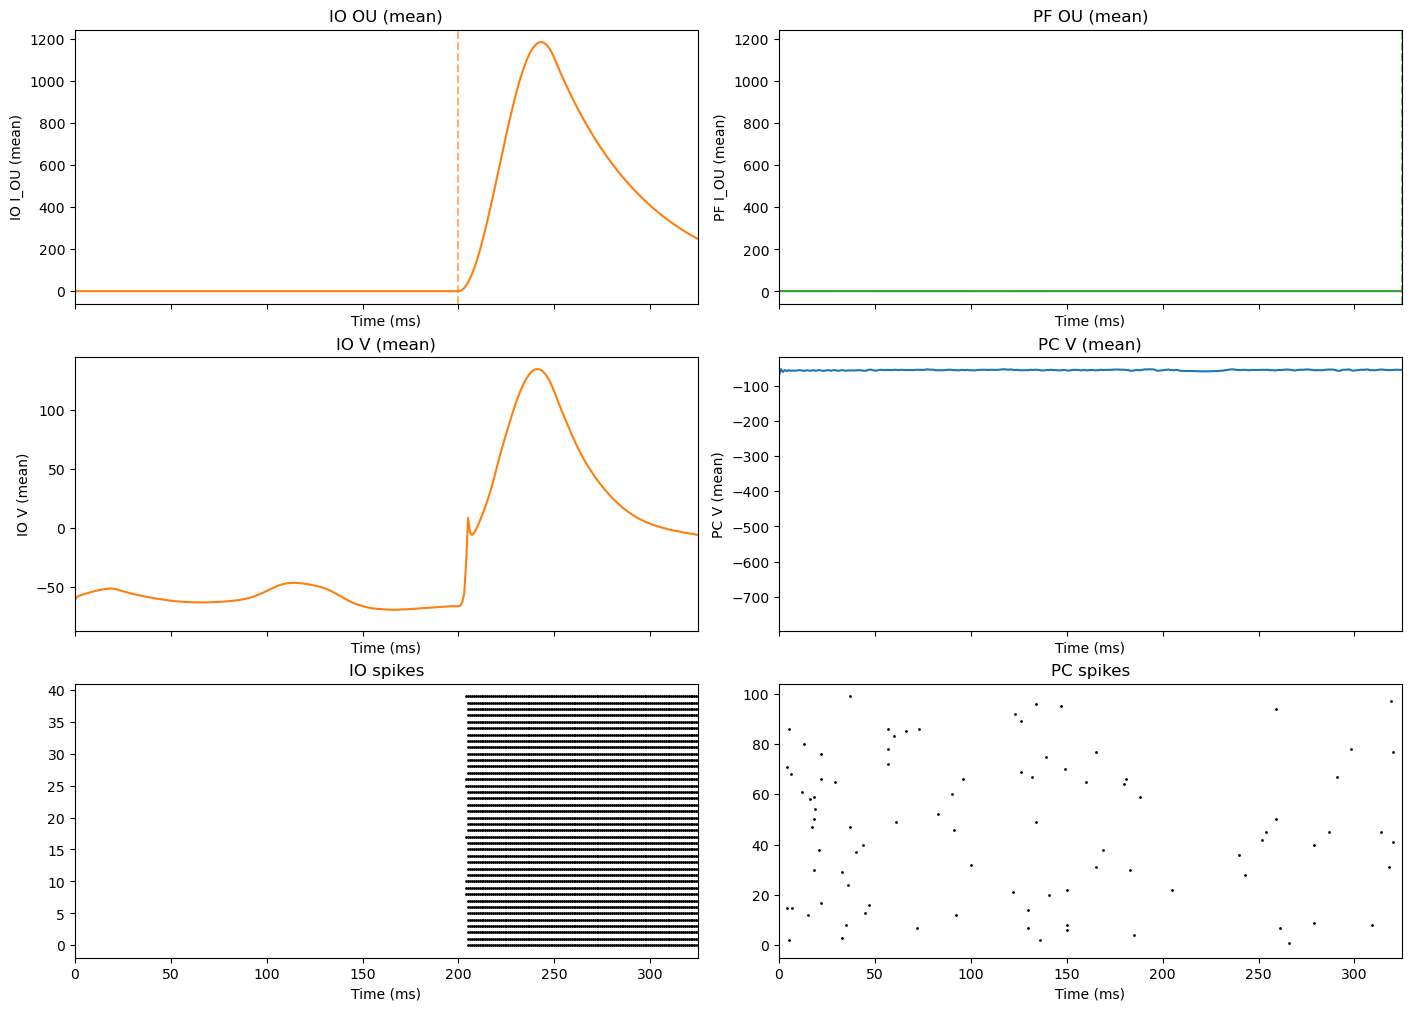

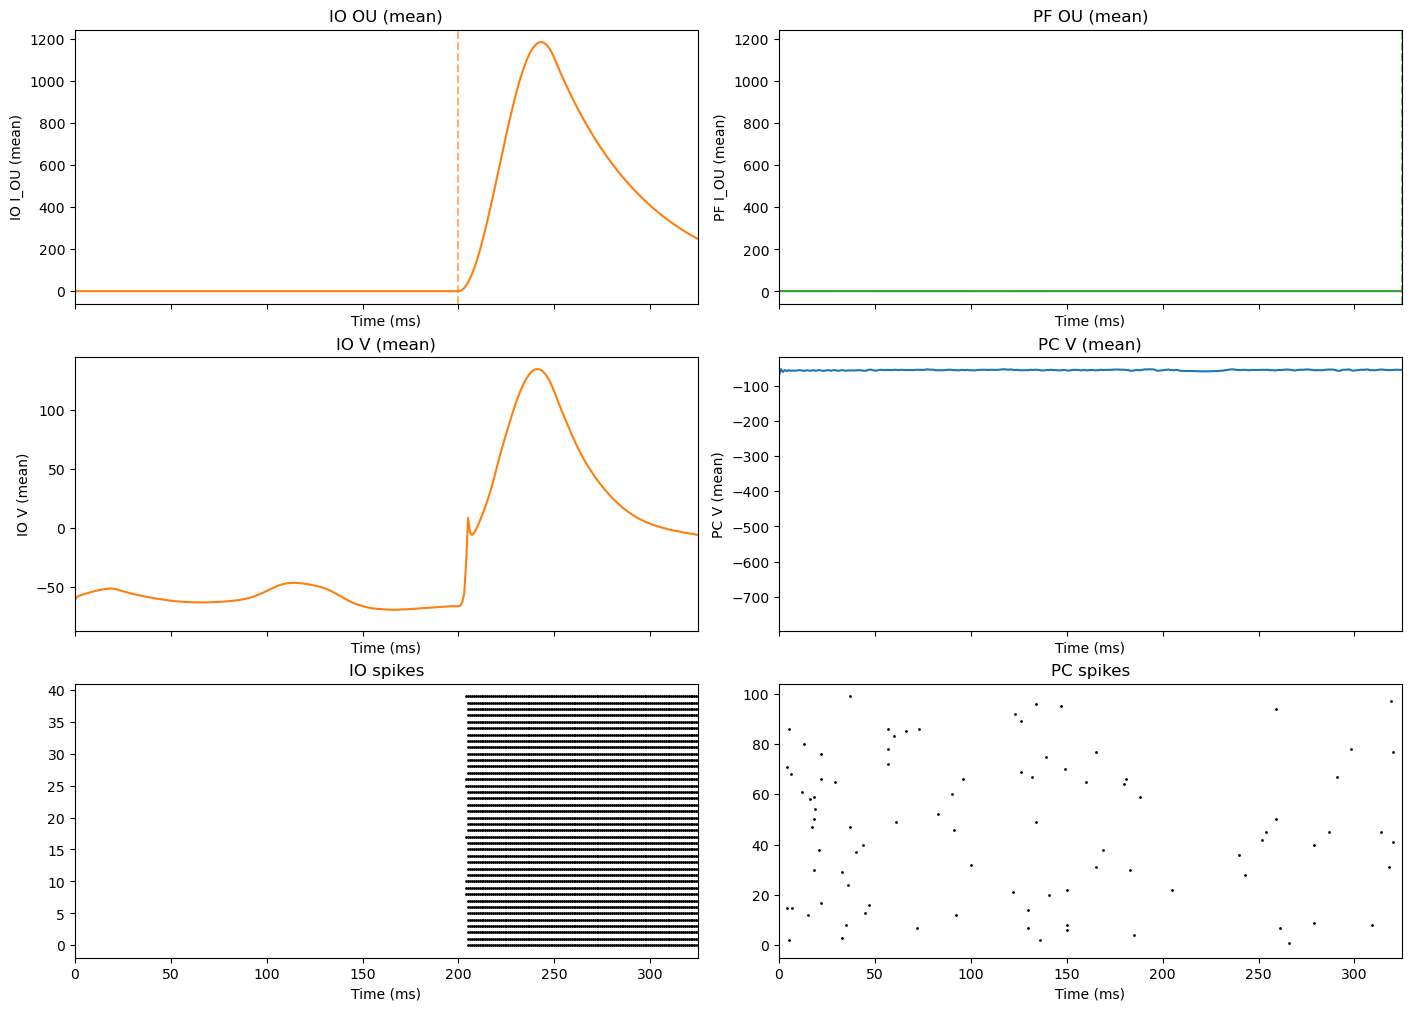

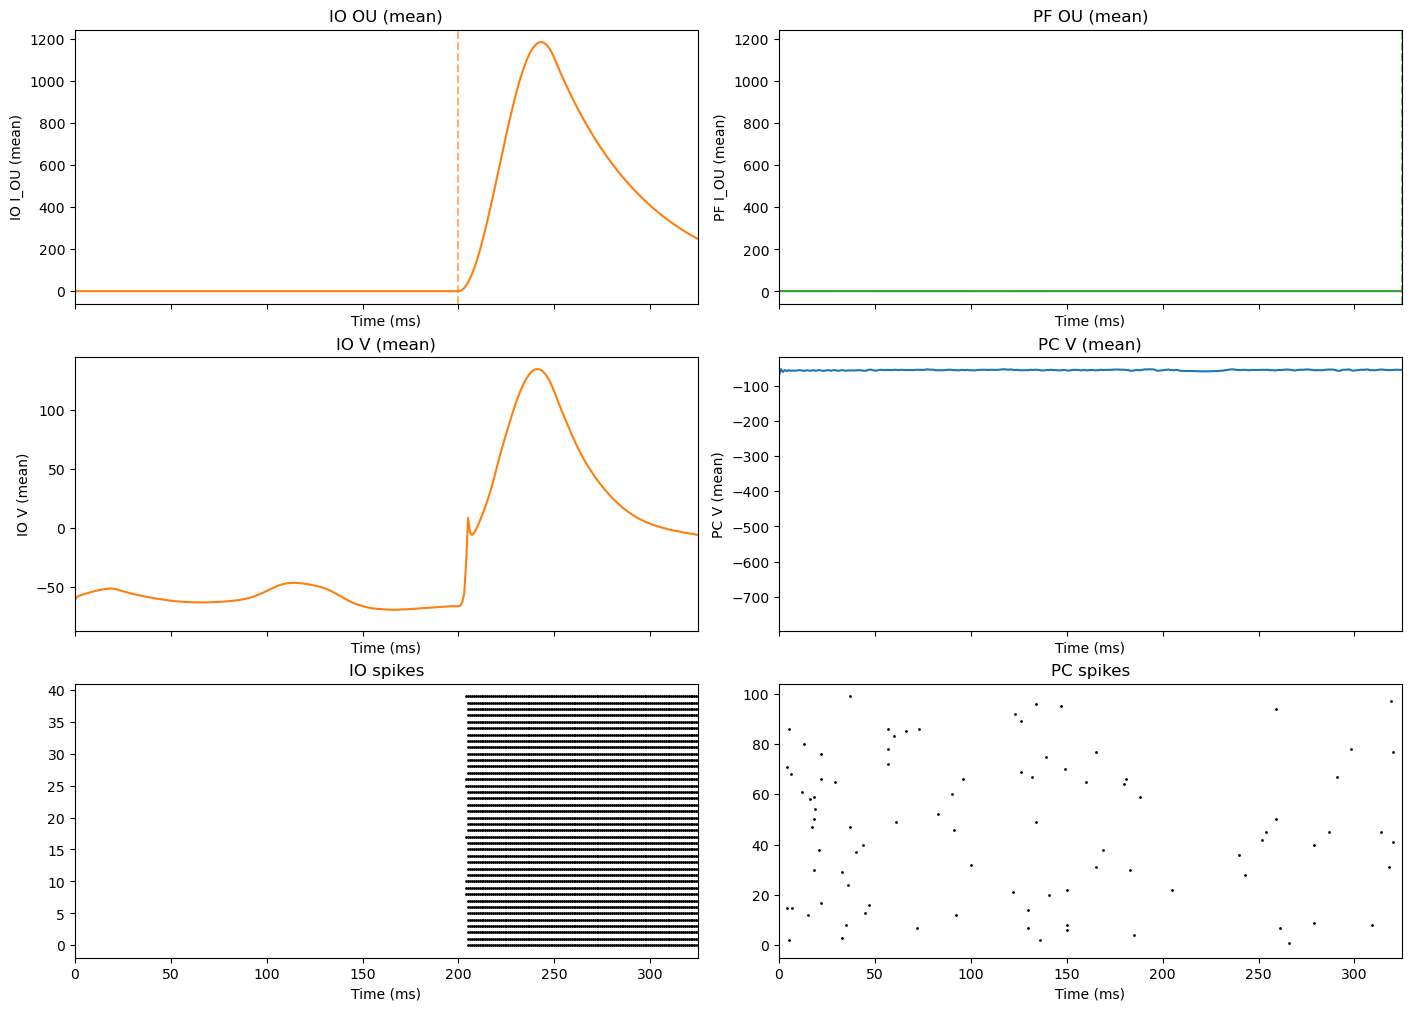

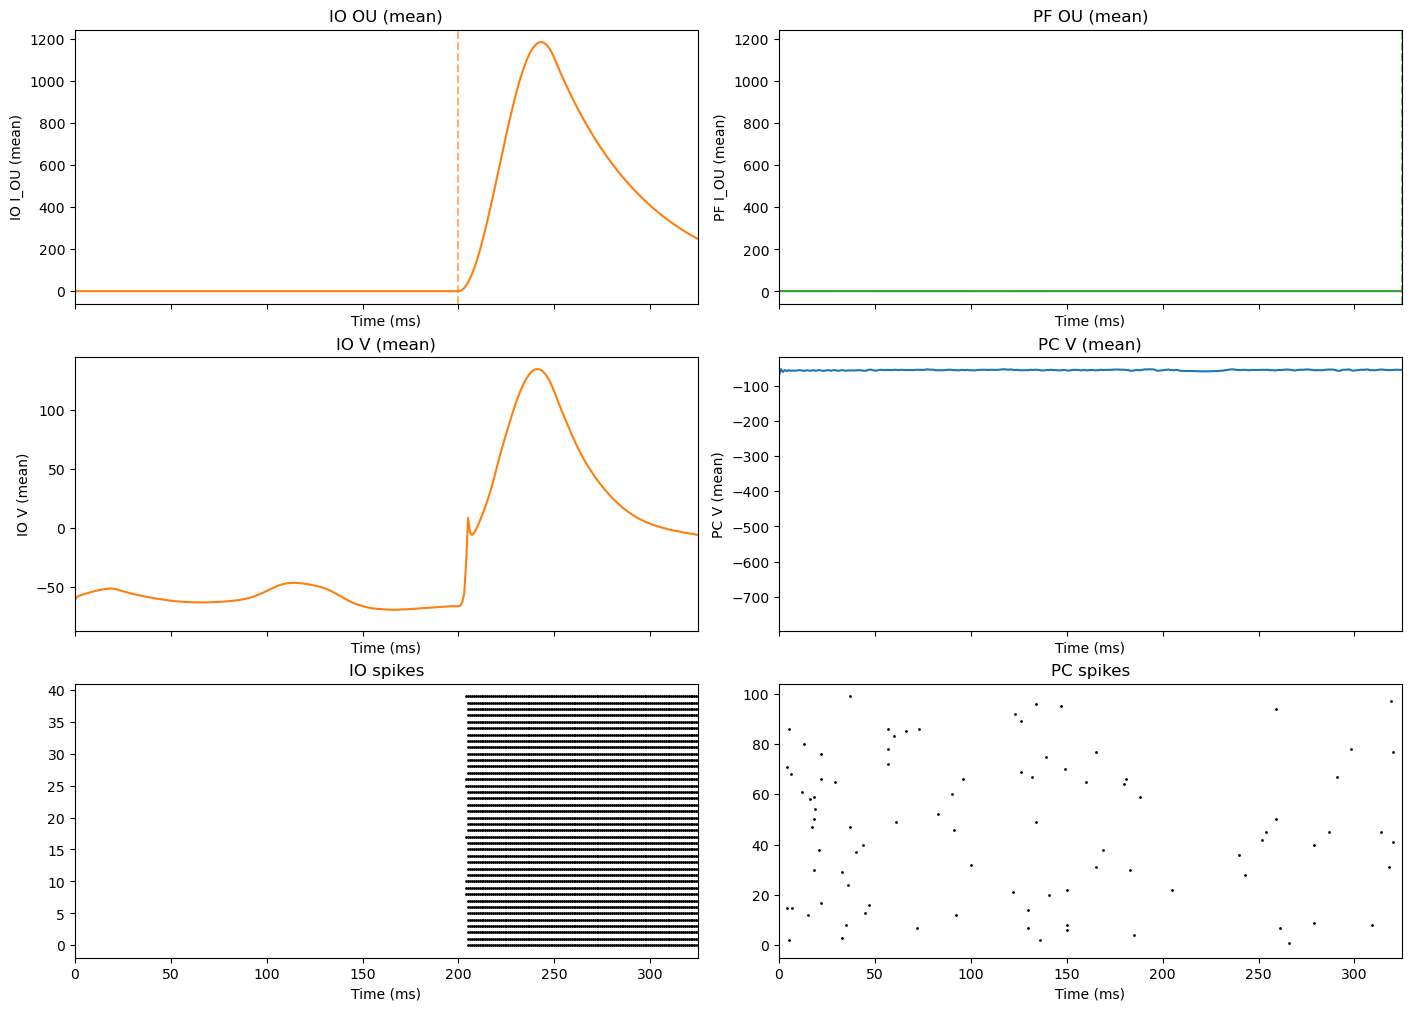

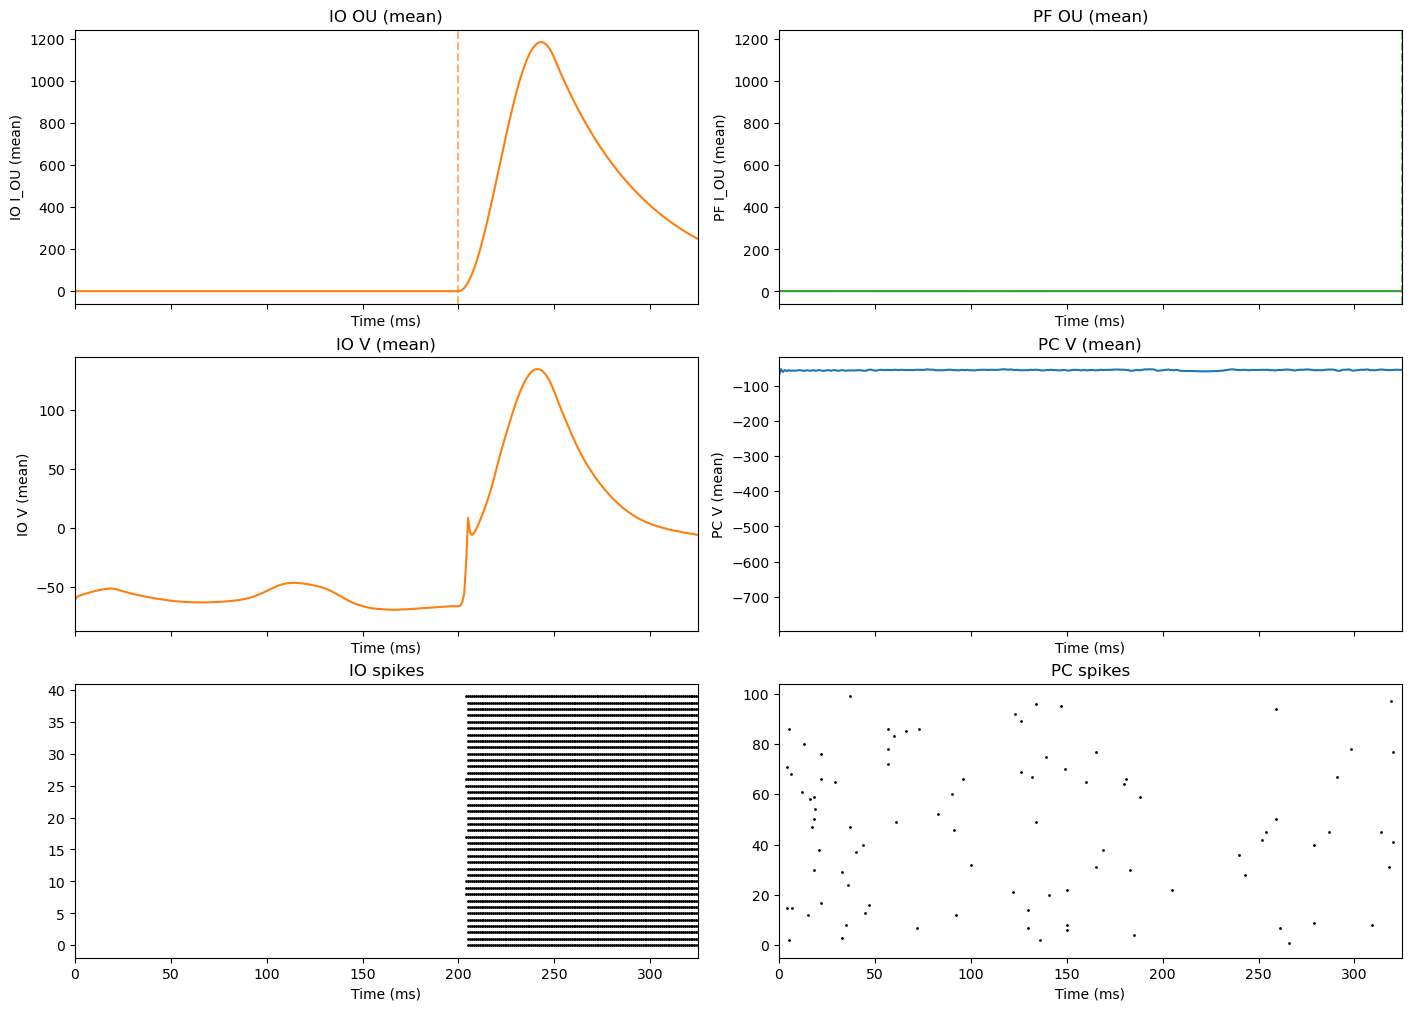

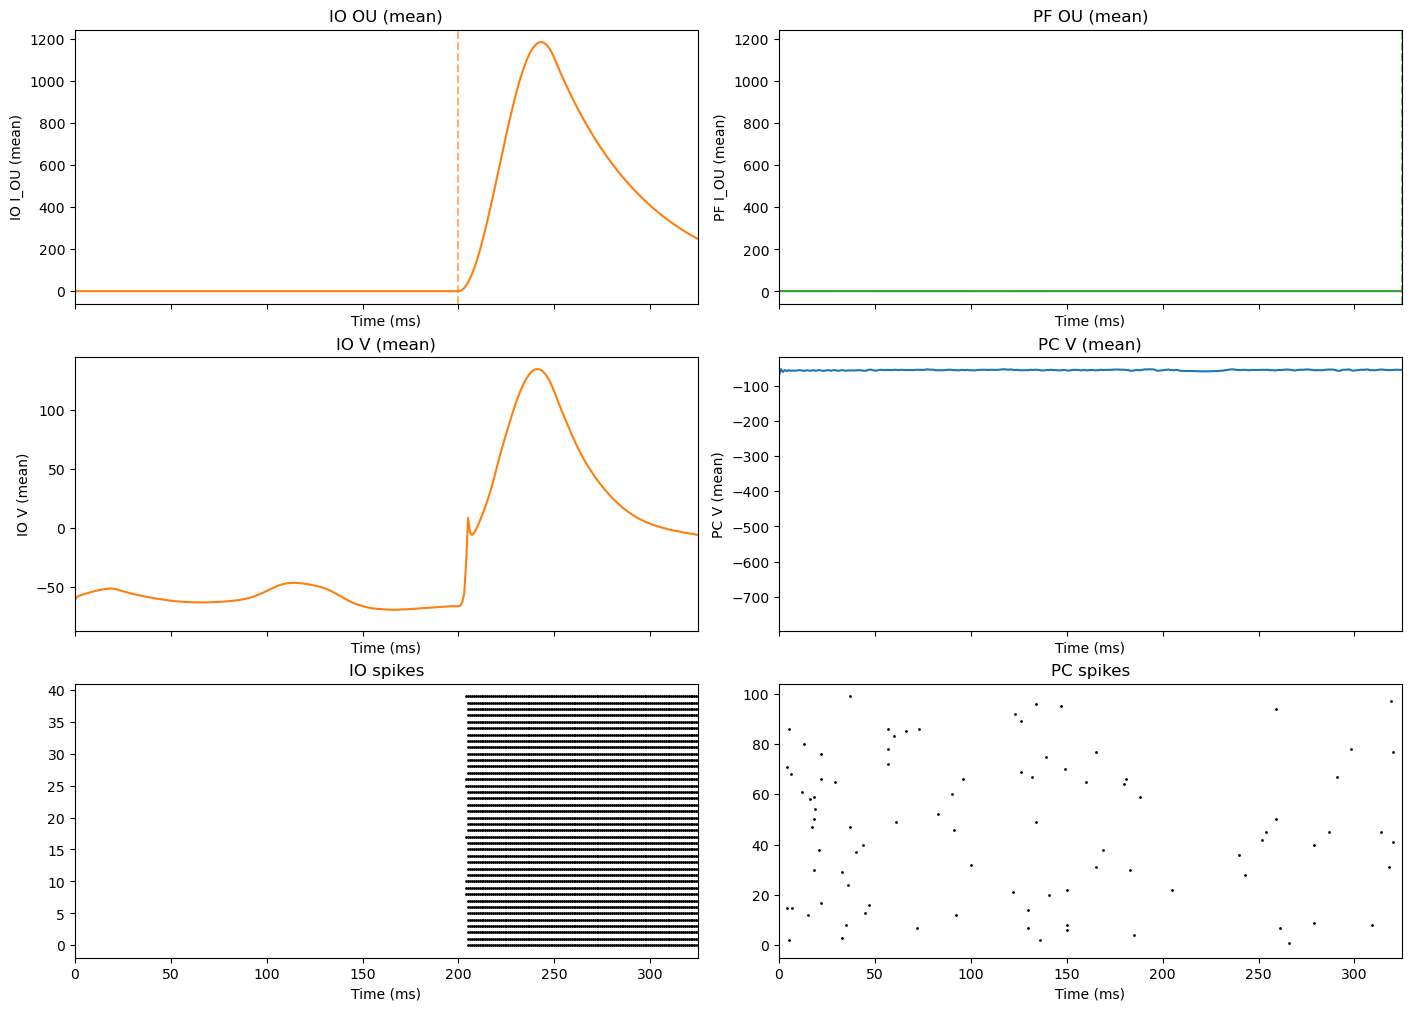

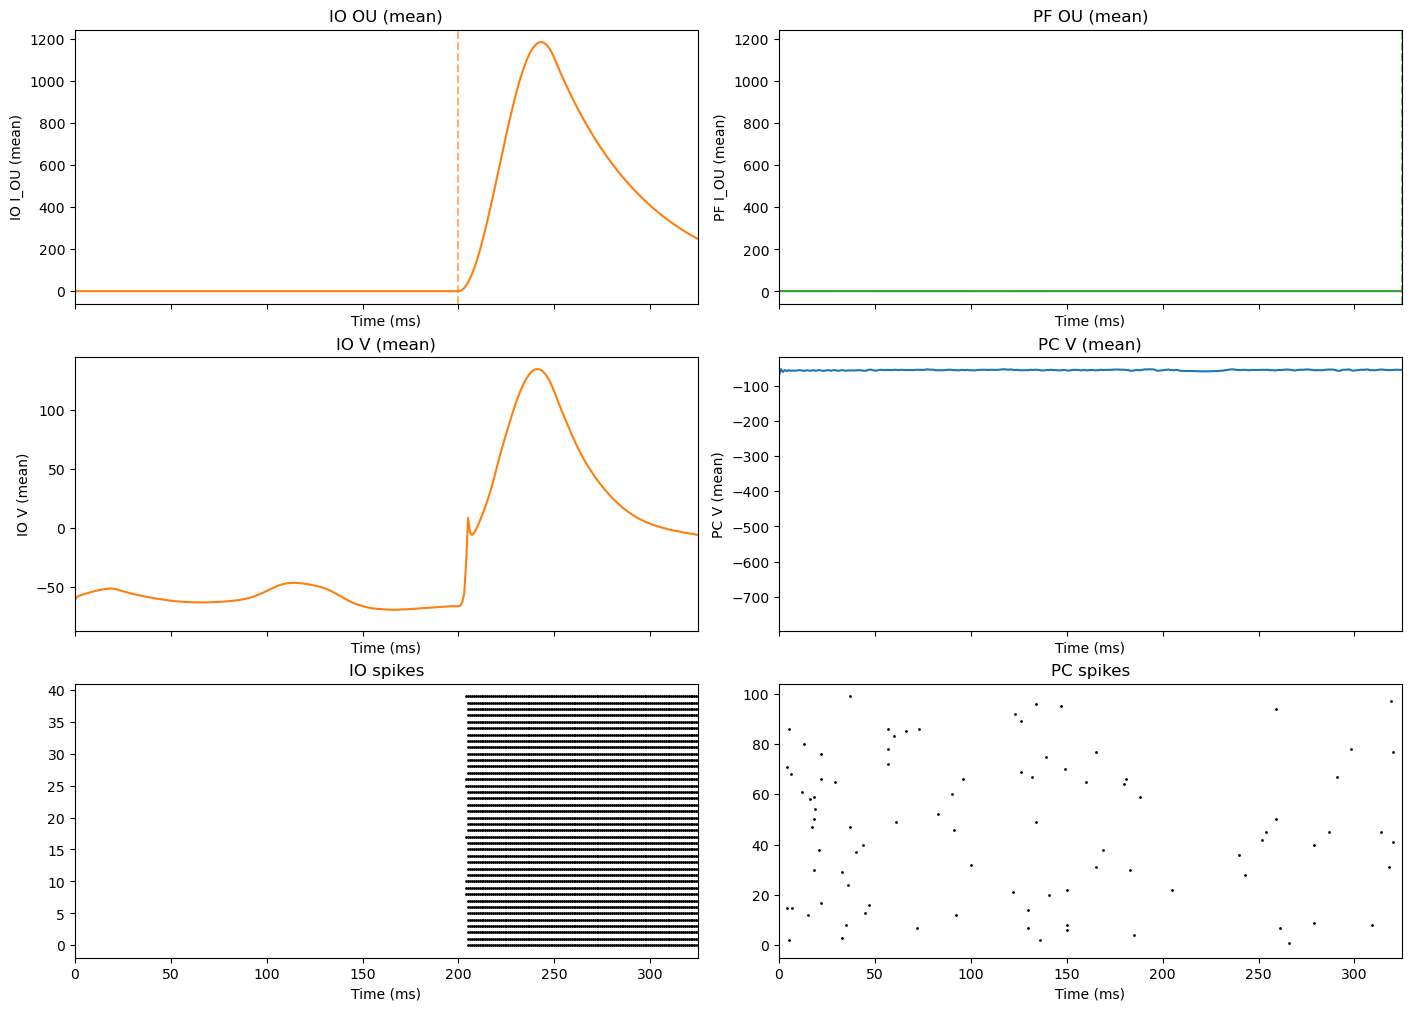

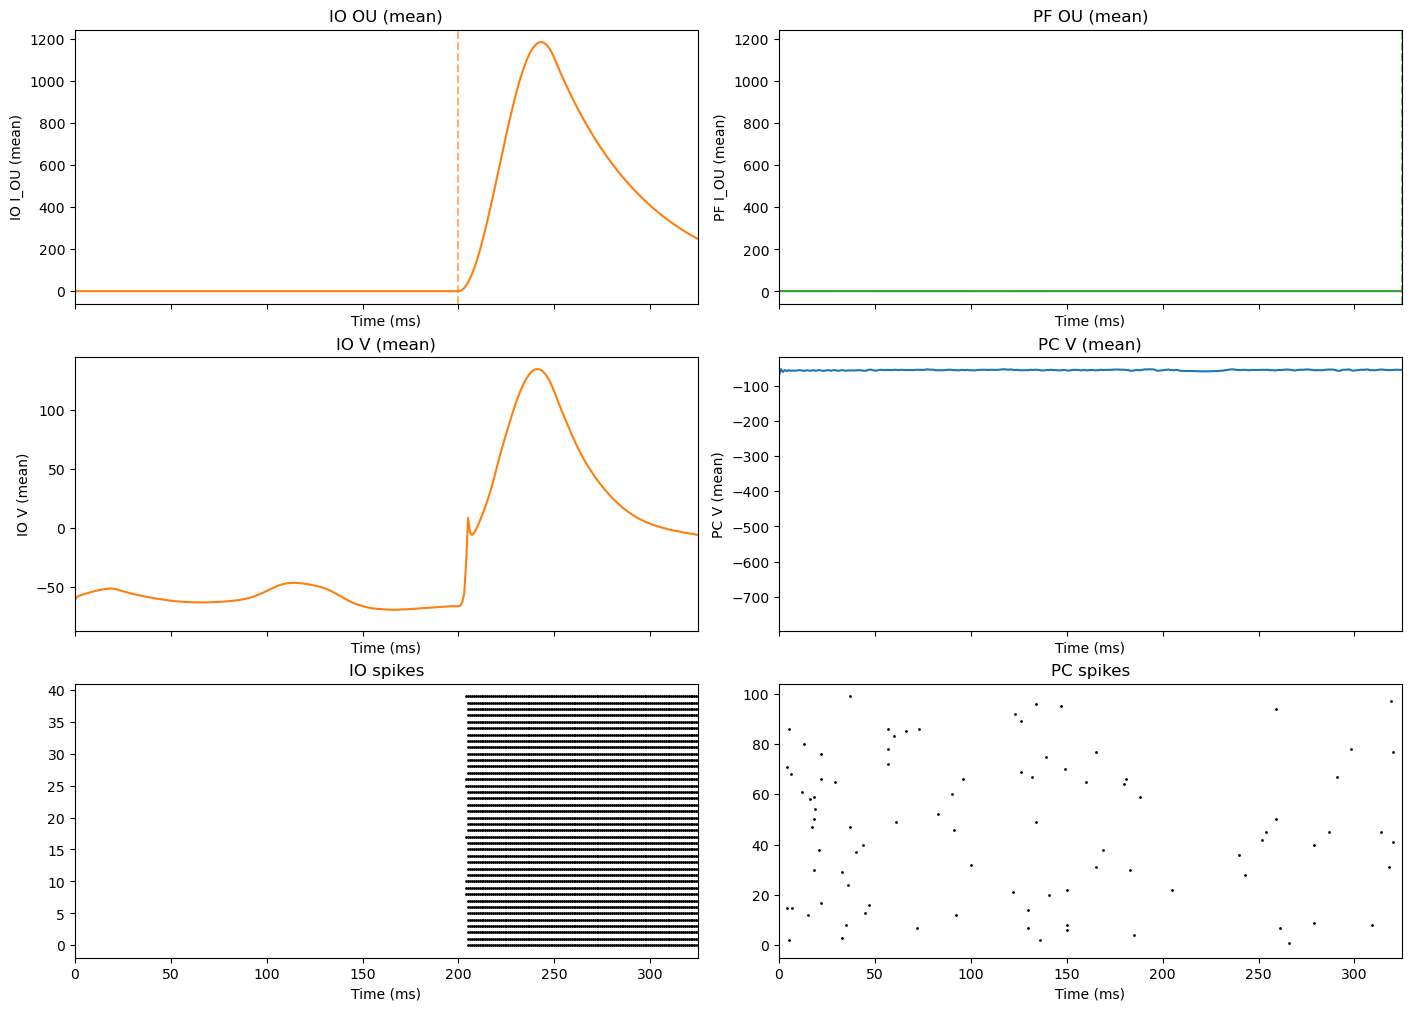

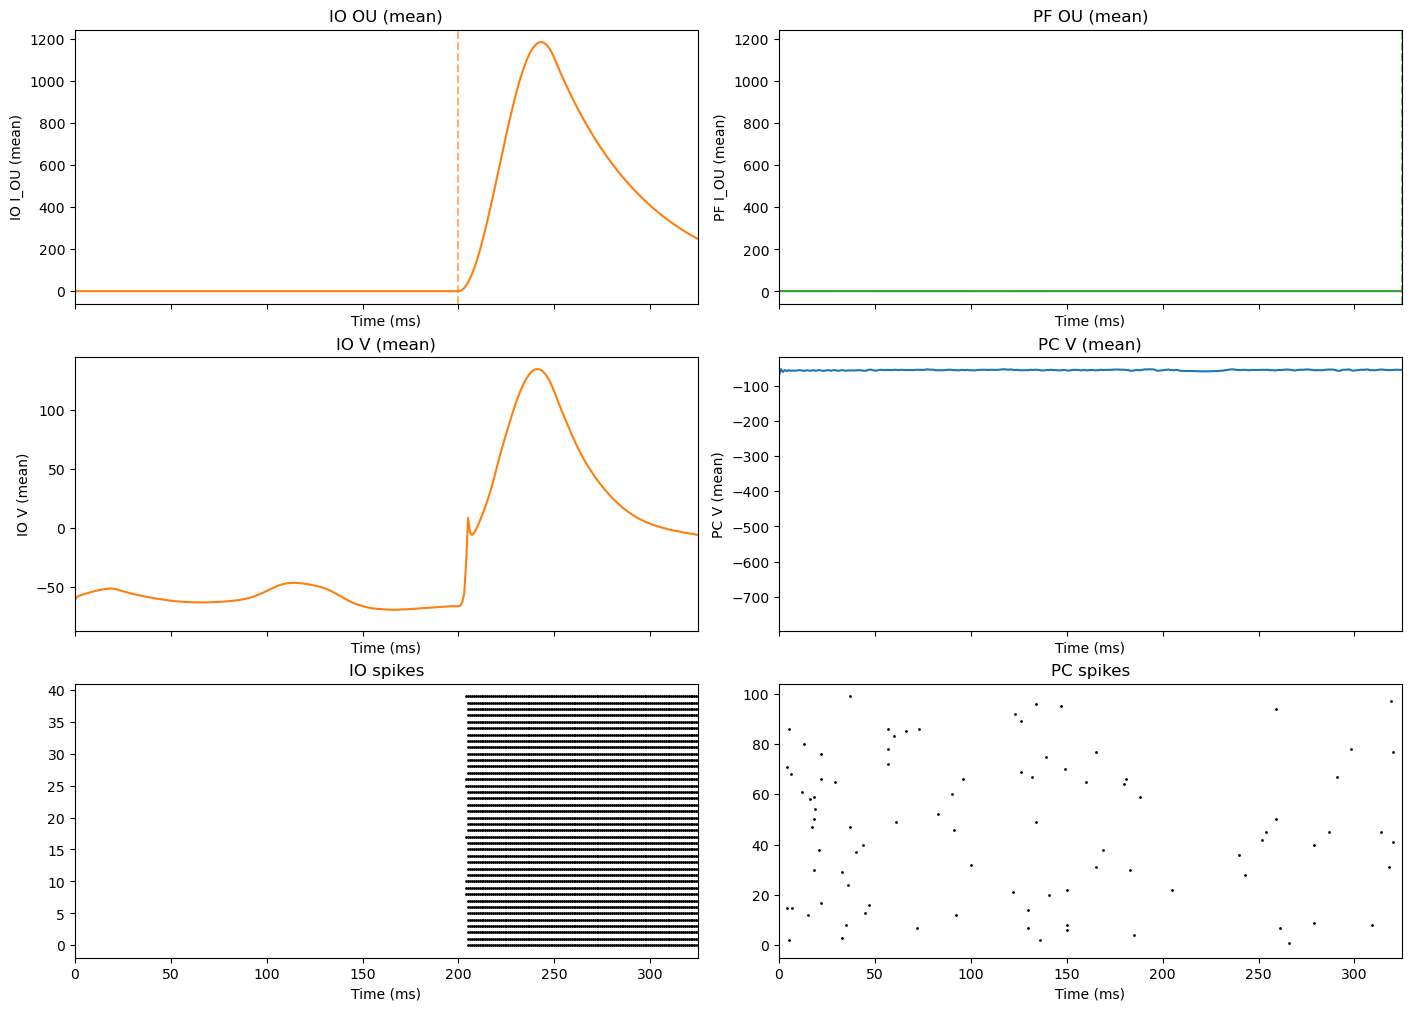

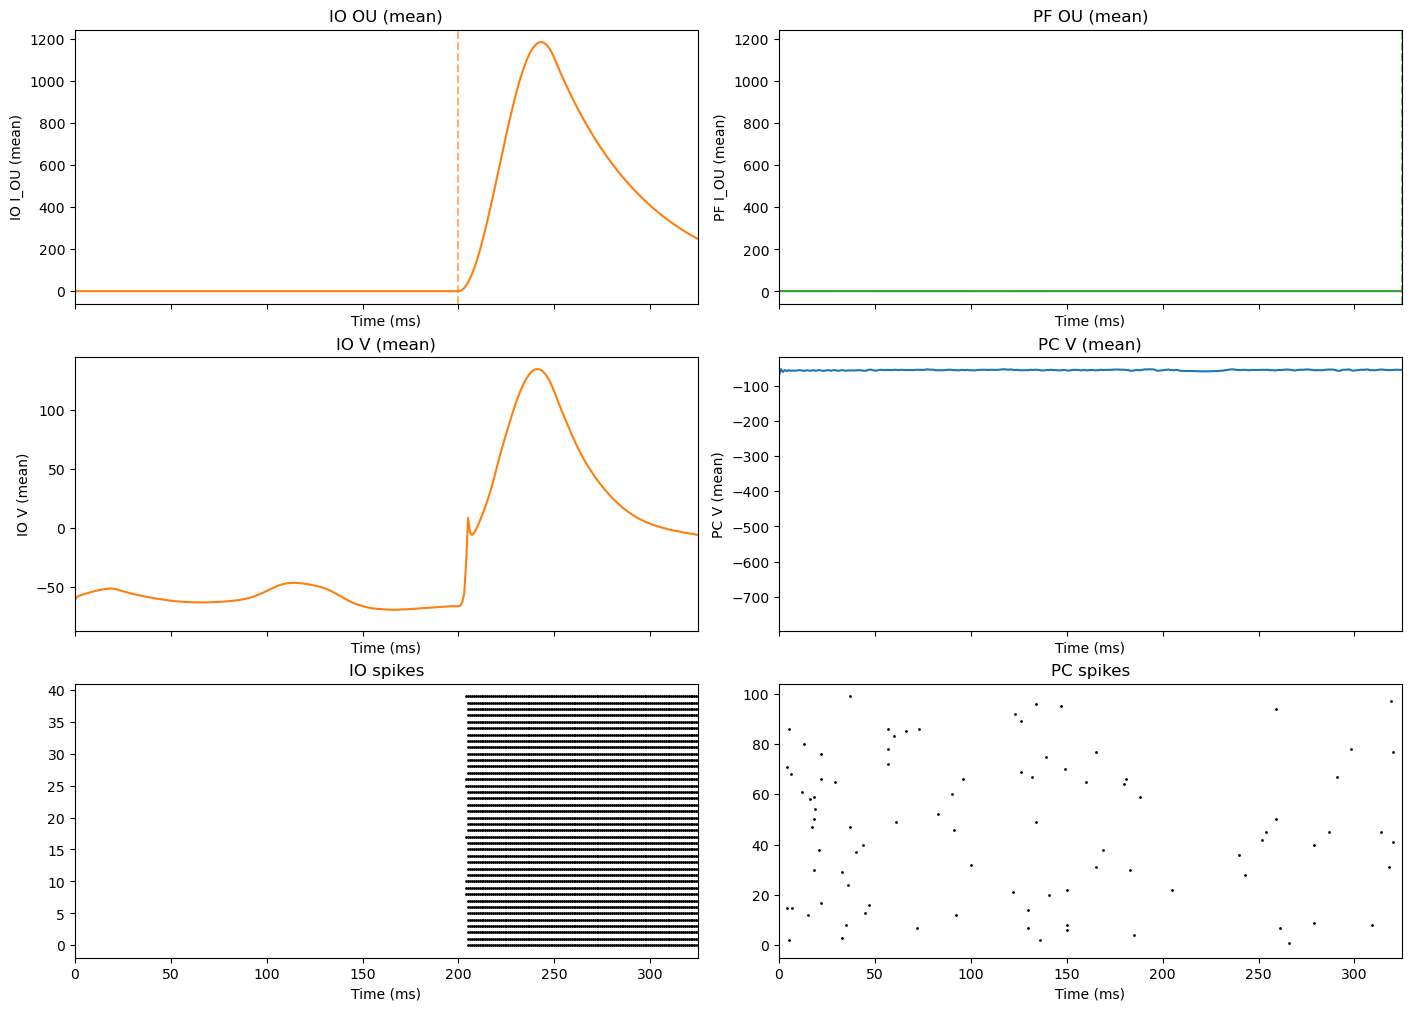

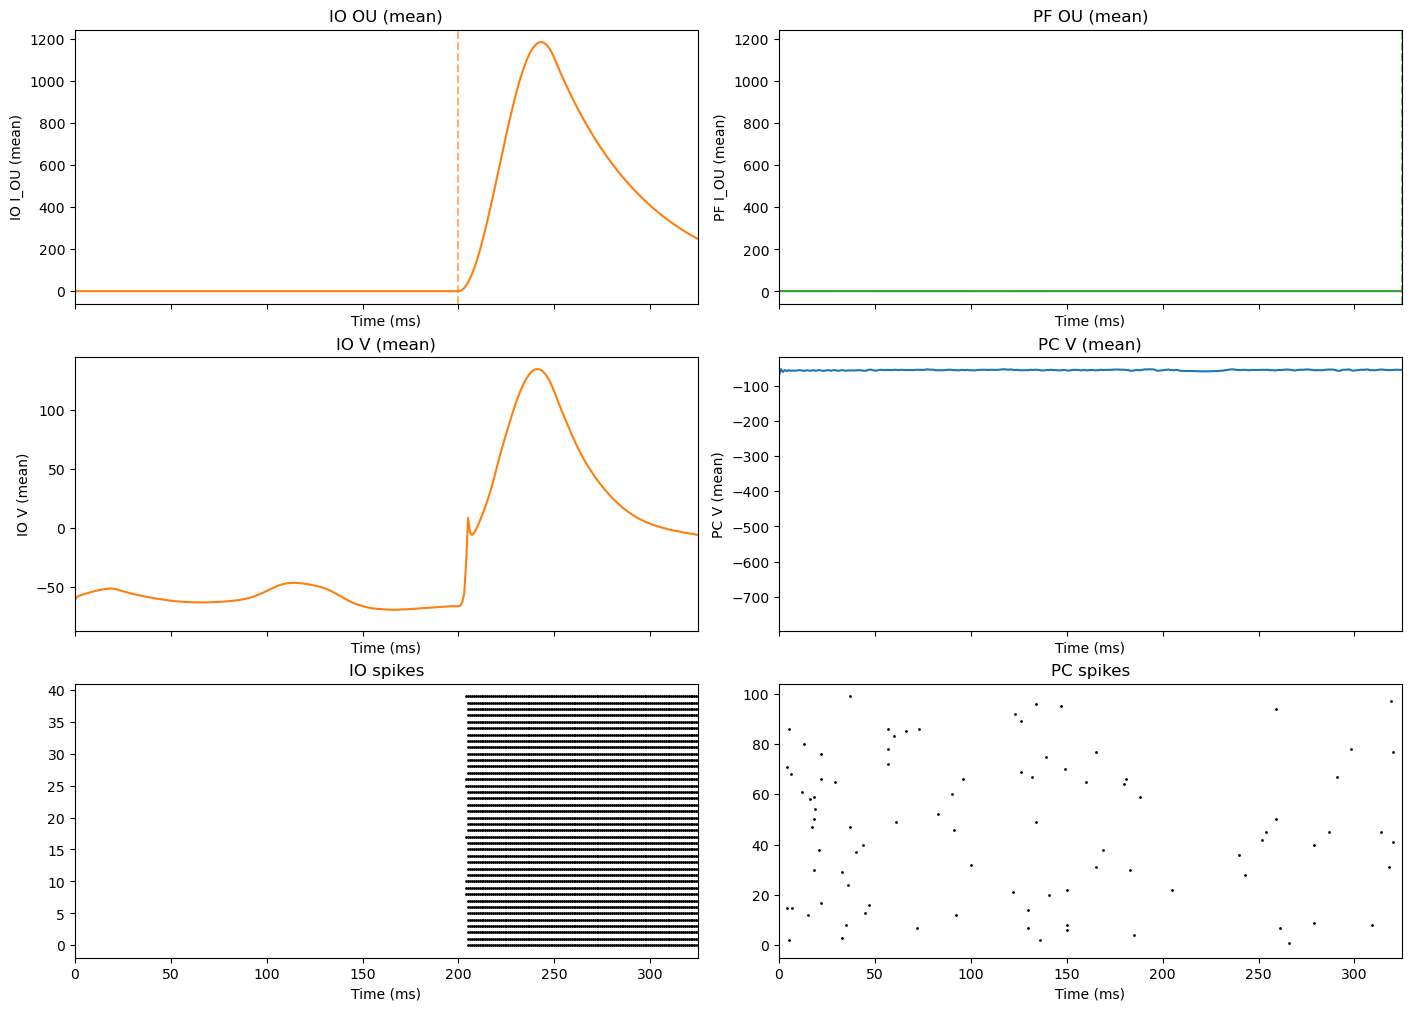

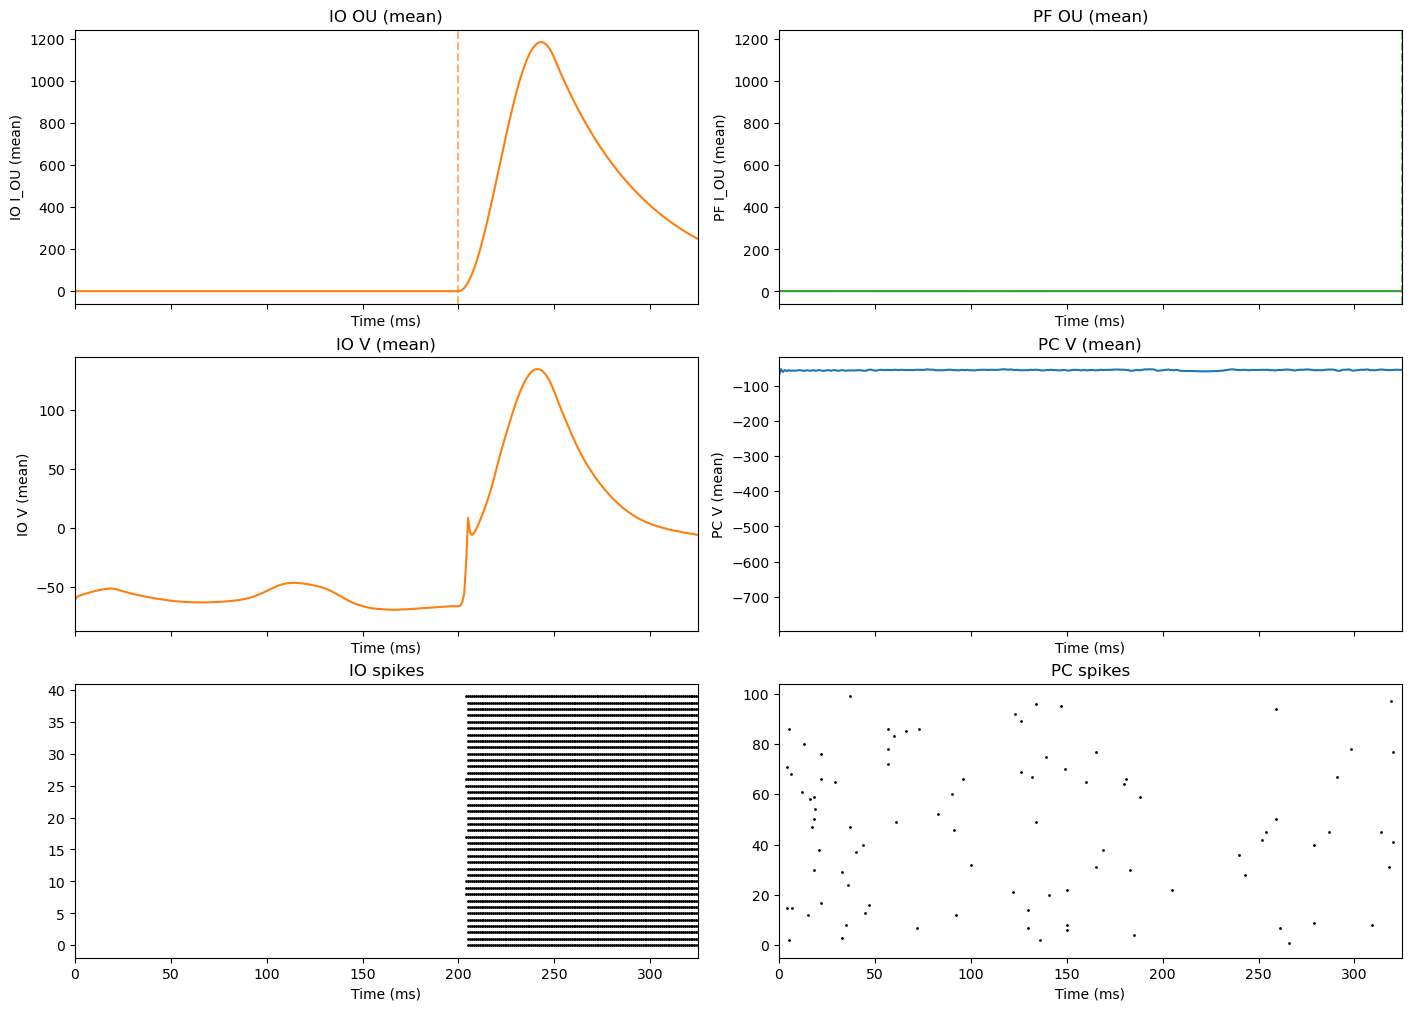

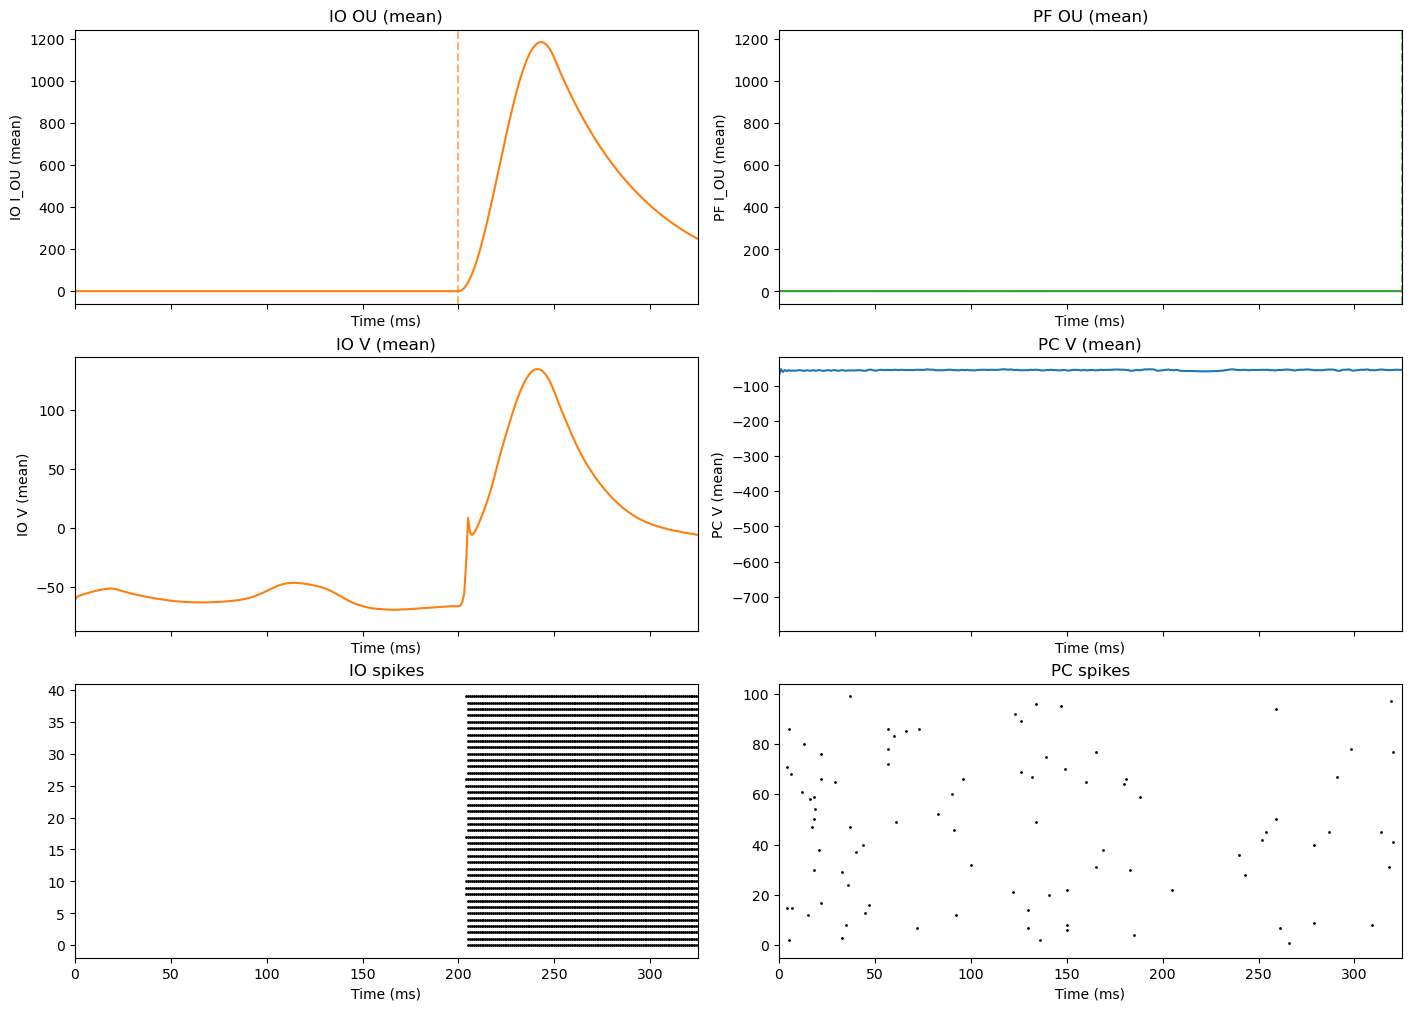

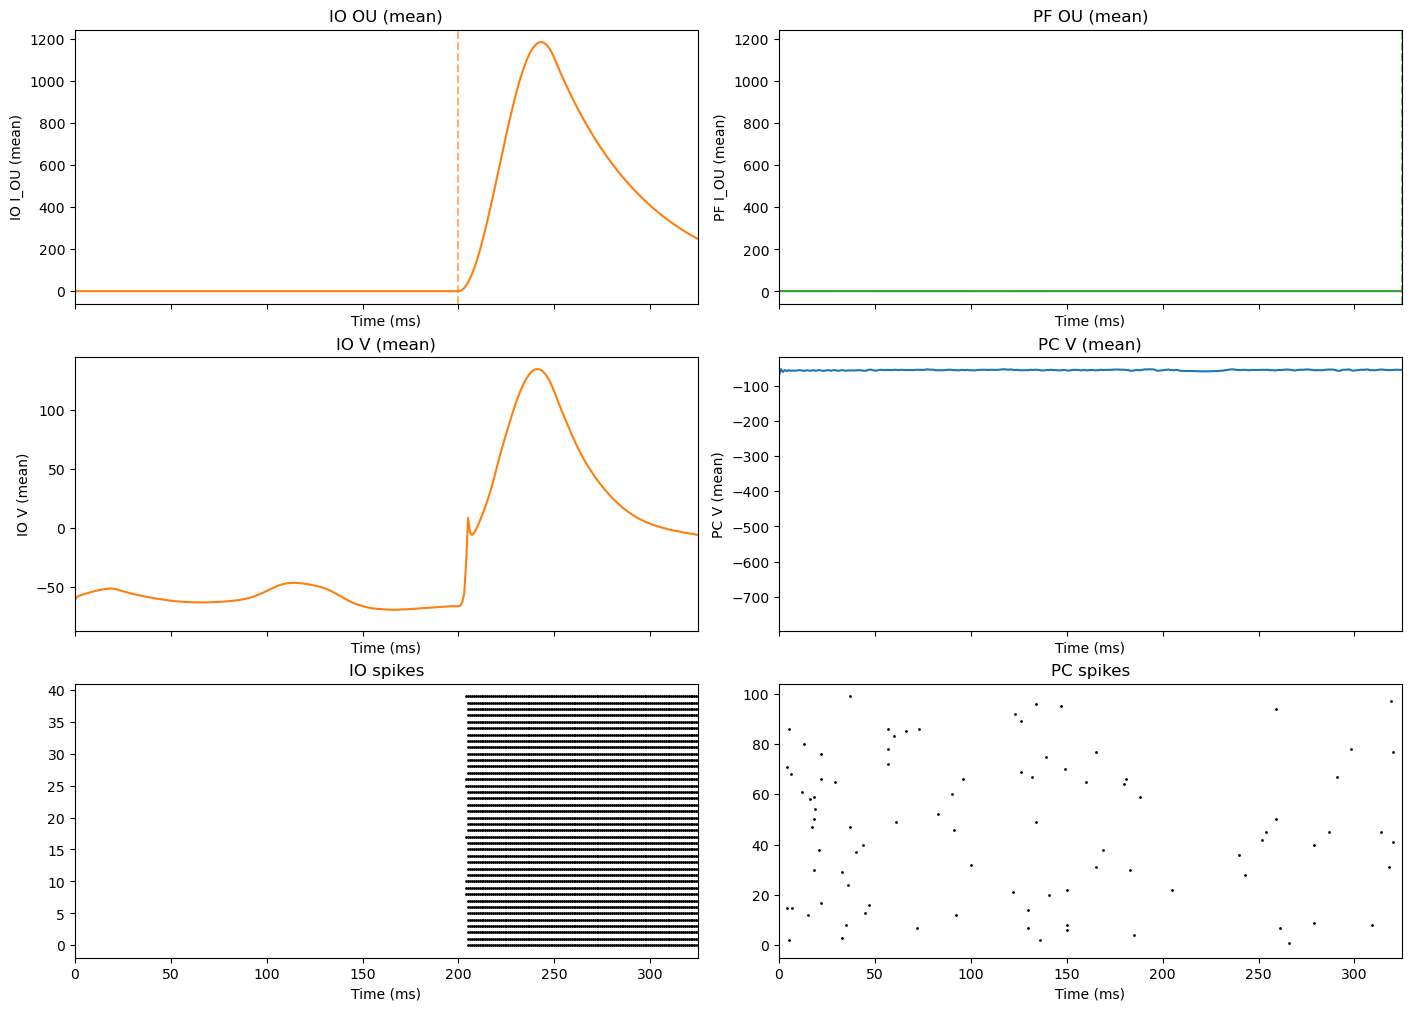

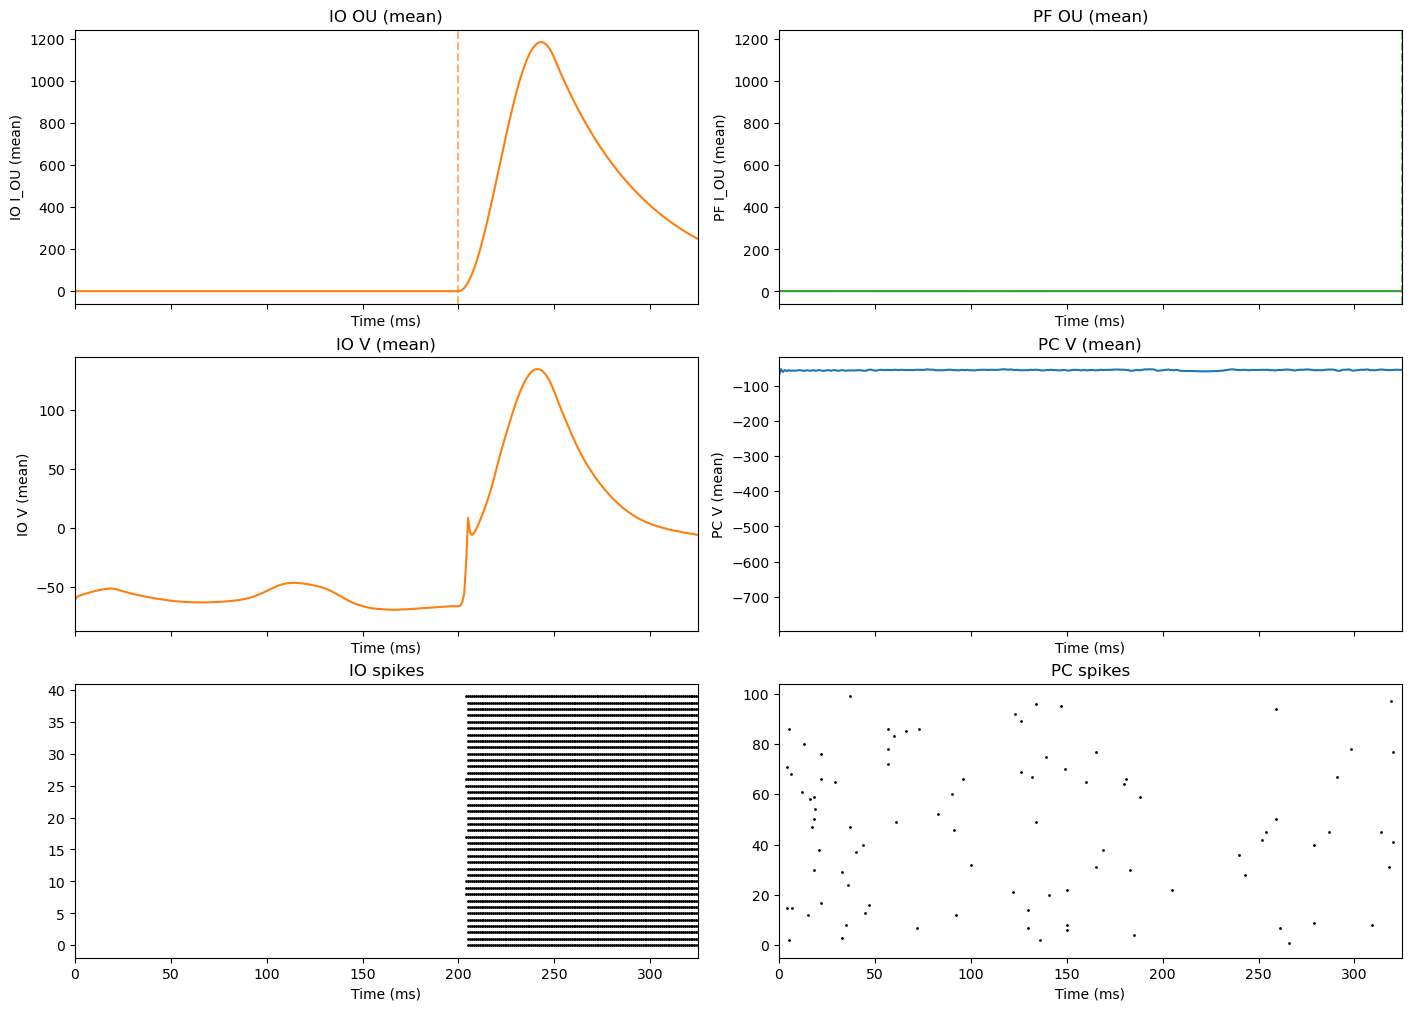

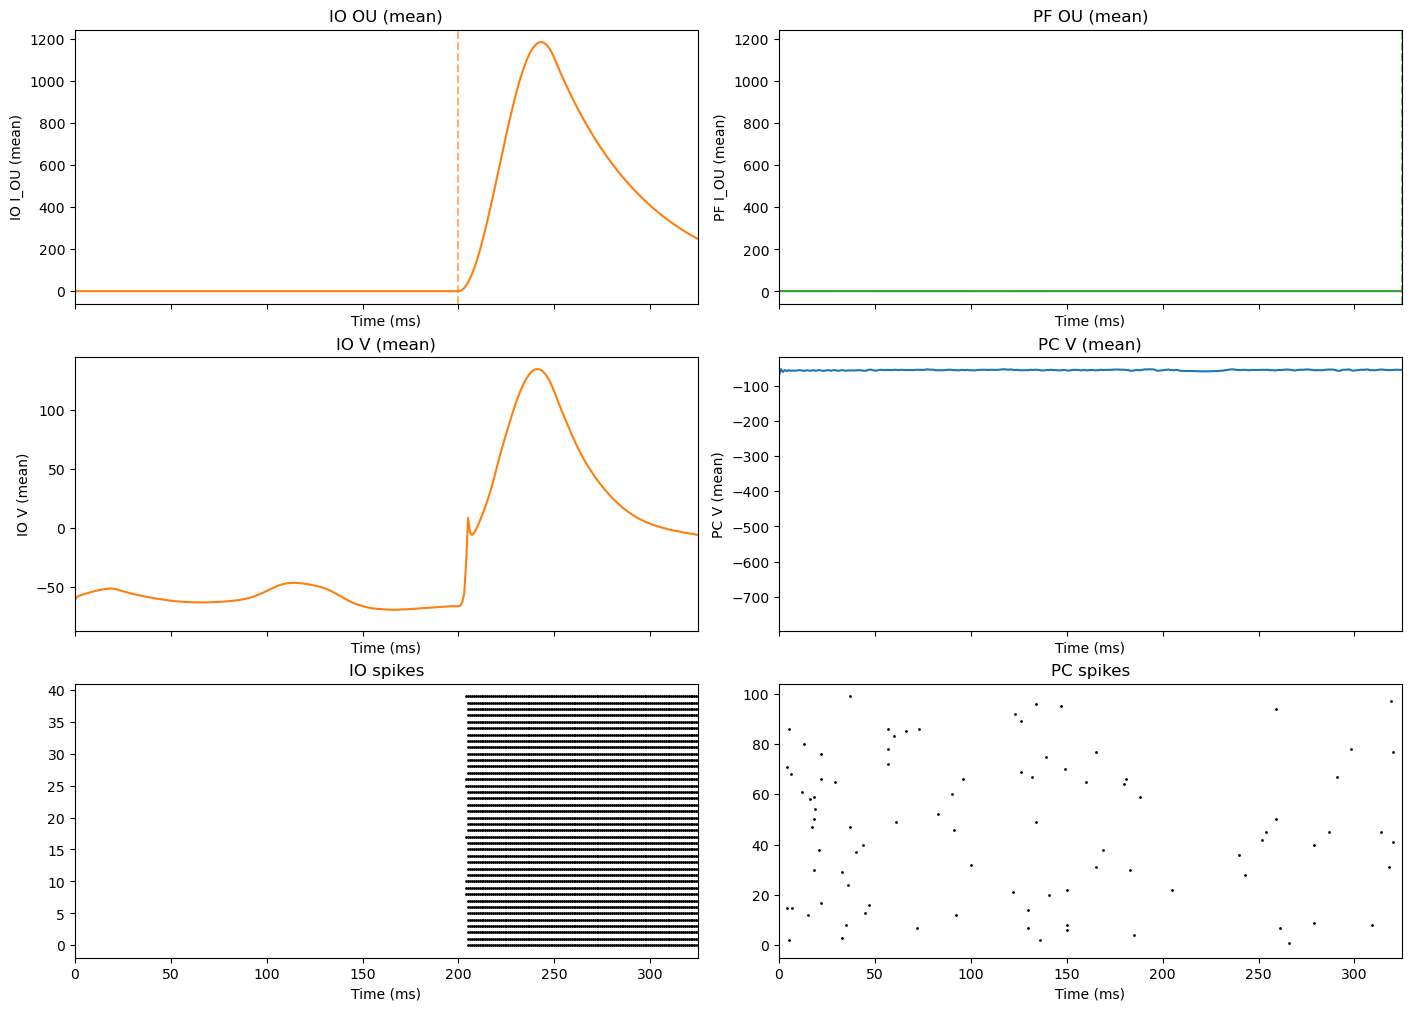

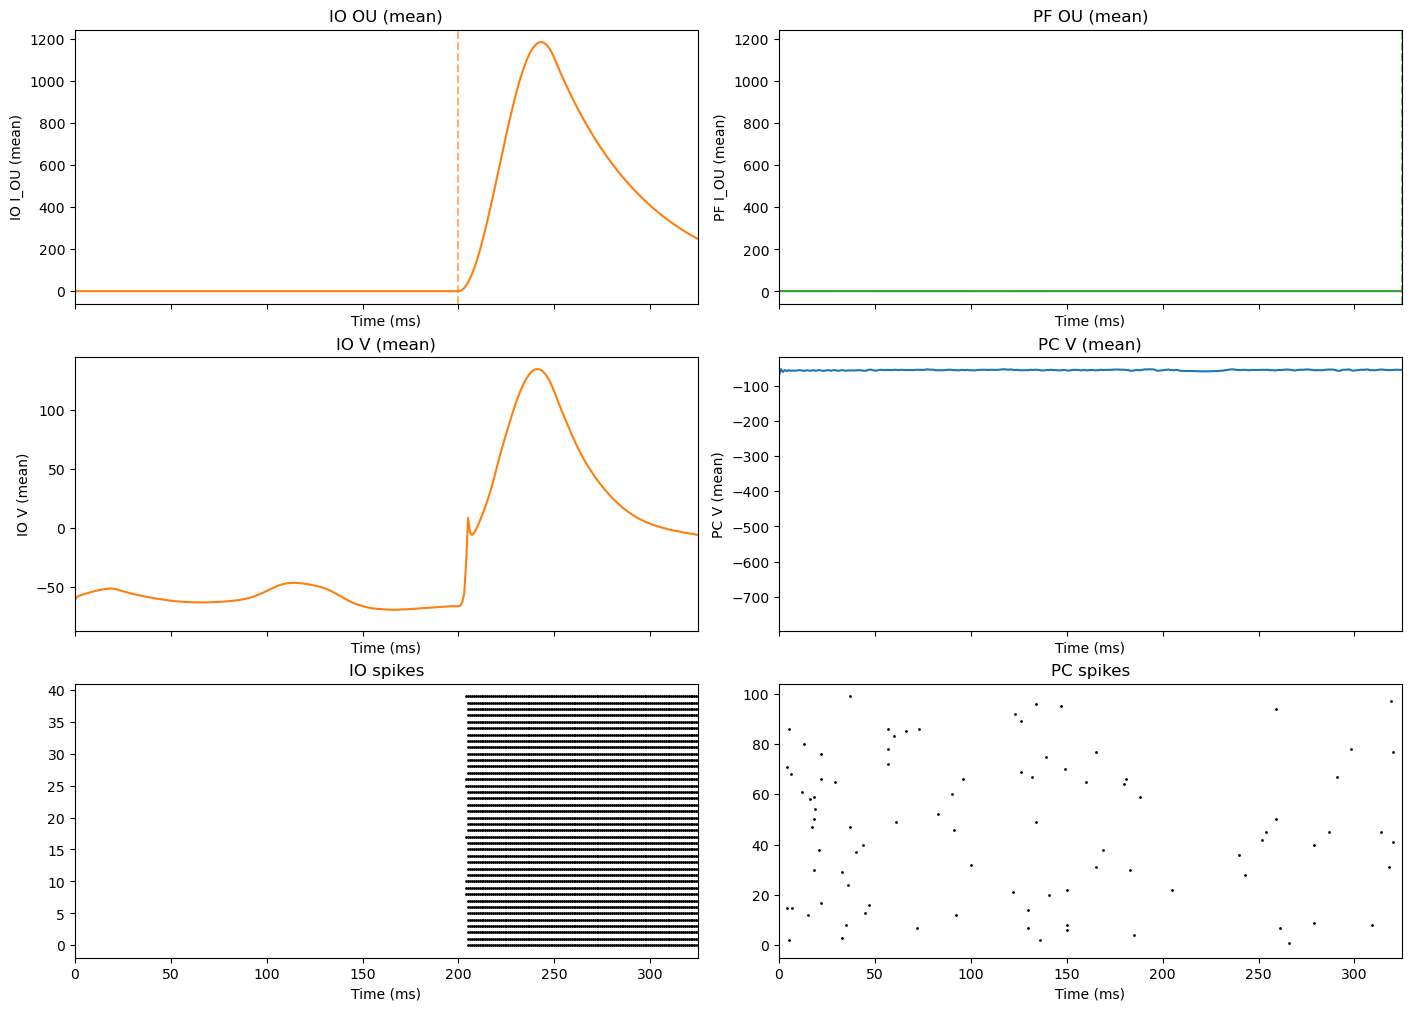

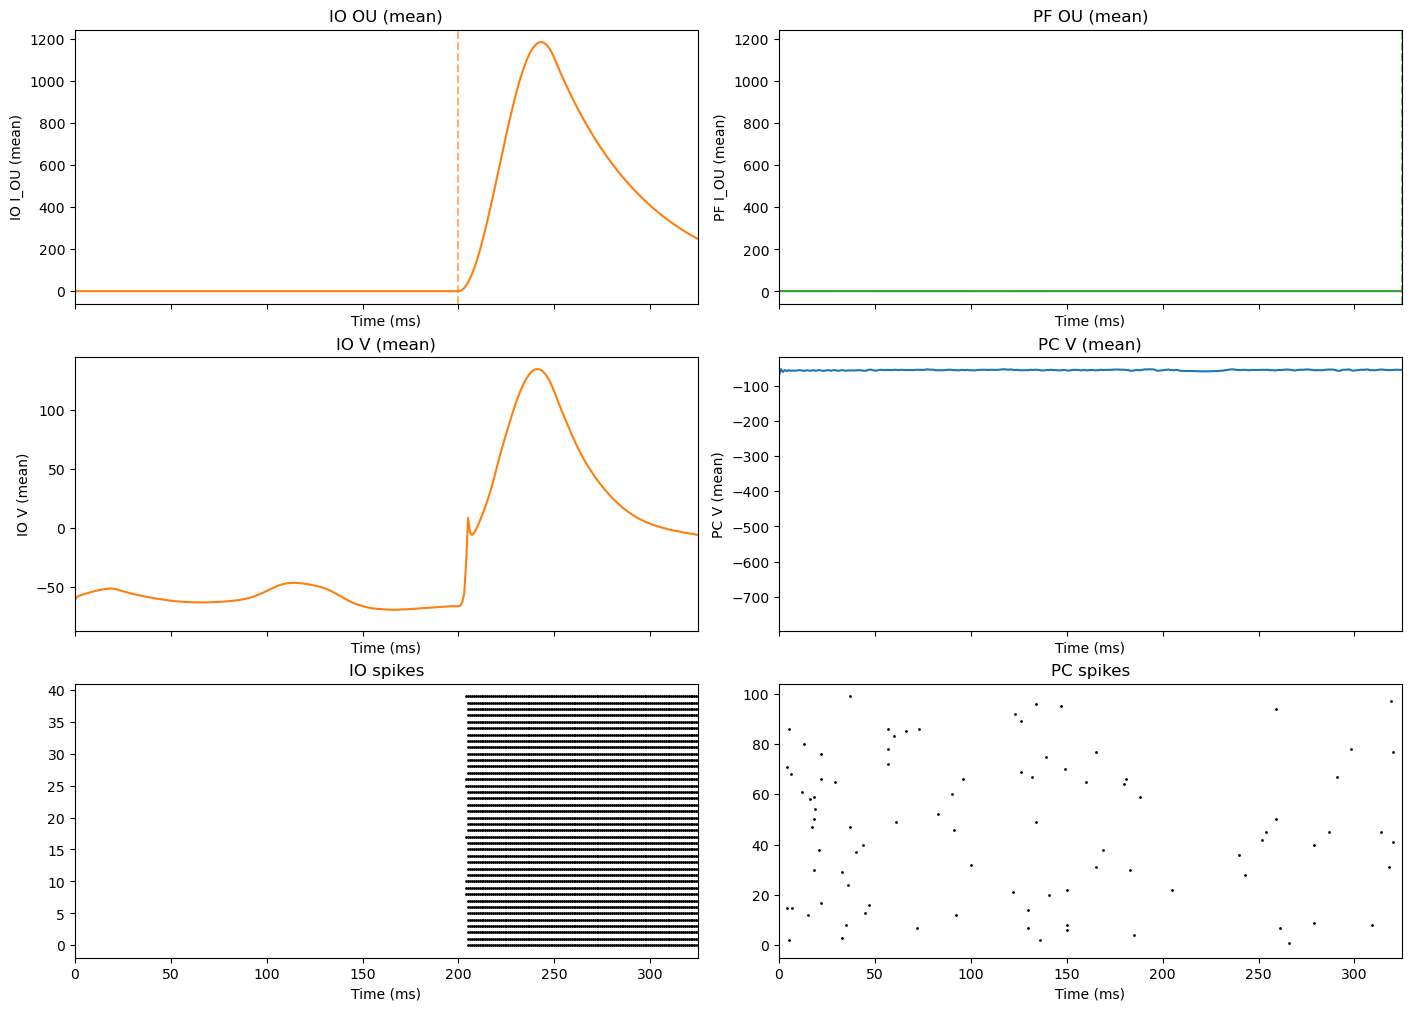

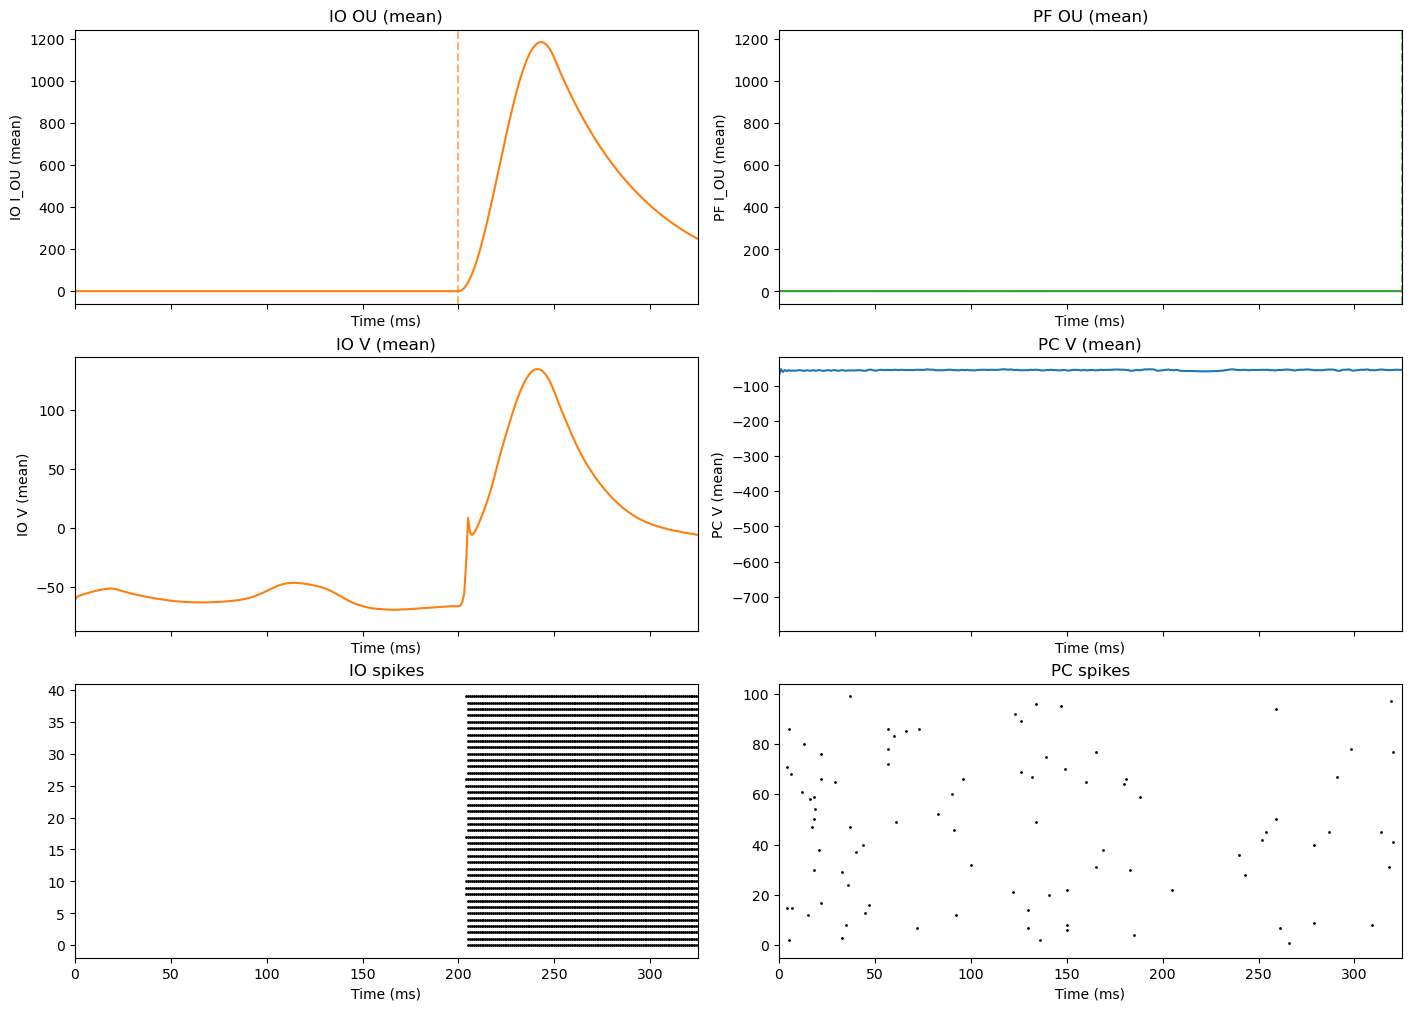

Saved 20 runs to data/datasets/fixed_isi_runs.npy


In [20]:
# Load fixed-ISI runs, build an inspectable dataset, and plot each run (6 subplots)
fixed_isi_paths = [job["run_path"] for job in jobs_variable_isi]
# container for quick inspection of multiple runs
fixed_isi_runs = []
os.makedirs(Path(parent_dir) / 'data' / 'datasets', exist_ok=True)

for dataset in fixed_isi_paths:
    if not os.path.exists(dataset):
        print('Missing dataset:', dataset)
        continue
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    # Safe getters (some keys may be missing for certain runs)
    pf_stim_start = data.get('stim_pf_start', np.array([]))
    io_stim_start = data.get('stim_io_start', np.array([]))

    pf_OU = data.get('pf.I_OU', None)
    pc_spike = data.get('pc.spike', None)
    pc_V = data.get('pc.V', None)
    pc_rho = data.get('pc.rho', None)

    io_OU = data.get('io.I_OU', None)
    io_spike = data.get('io.spike', None)
    io_V = data.get('io.V_soma', None)

    ts = data.get('ts', None)
    if ts is None:
        # fallback: infer time axis from first available array
        candidate = pf_OU if pf_OU is not None else io_OU if io_OU is not None else pc_V
        if candidate is None:
            print('Cannot infer time axis for', dataset)
            continue
        ts = np.arange(candidate.shape[0])

    # store minimal run summary for later inspection
    meta = {'path': dataset, 'seed': data.get('seed', None), 'isi': data.get('isi', None)}
    fixed_isi_runs.append({'meta': meta, 'ts': ts, 'pf_OU': pf_OU, 'io_OU': io_OU, 'pc_V': pc_V, 'io_V': io_V, 'pc_spike': pc_spike, 'io_spike': io_spike, 'pf_stim_start': pf_stim_start, 'io_stim_start': io_stim_start})

    # Create 3x2 figure: row1 OU (IO, PF), row2 V (IO, PC), row3 spikes (IO, PC)
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, constrained_layout=True)
    ax = axes.ravel()

    # OU: plot mean across units if available
    if io_OU is not None:
        ax[0].plot(ts, np.nanmean(io_OU, axis=1), color='tab:orange')
        ax[0].set_ylabel('IO I_OU (mean)')
        ax[0].set_title('IO OU (mean)')
        ax[0].set_xlim(0, io_stim_start[0])
    else:
        ax[0].text(0.5, 0.5, 'no io.OU', ha='center', va='center')

    if pf_OU is not None:
        ax[1].plot(ts, np.nanmean(pf_OU, axis=1), color='tab:green')
        ax[1].set_ylabel('PF I_OU (mean)')
        ax[1].set_title('PF OU (mean)')
        ax[1].set_xlim(0, pf_stim_start[0])
    else:
        ax[1].text(0.5, 0.5, 'no pf.OU', ha='center', va='center')

    # mark stimulus starts: helper that handles boolean masks or time lists
    def mark_starts(axx, starts, color='red'):
        if starts is None:
            return
        arr = np.asarray(starts)
        if arr.size == 0:
            return
        if arr.dtype == bool or arr.dtype == np.bool_:
            times = ts[arr]
        else:
            times = arr
        # if times look like indices (integers within range), map to ts values
        if np.issubdtype(times.dtype, np.integer) and np.max(times) < len(ts):
            times = ts[np.asarray(times, dtype=int)]
        for t in np.unique(times):
            axx.axvline(t, color=color, linestyle='--', alpha=0.6)

    mark_starts(ax[0], io_stim_start, color='tab:orange')
    mark_starts(ax[1], pf_stim_start, color='tab:green')

    # Membrane potentials (mean across units)
    if io_V is not None:
        ax[2].plot(ts, np.nanmean(io_V, axis=1), color='tab:orange')
        ax[2].set_ylabel('IO V (mean)')
        ax[2].set_title('IO V (mean)')
        ax[2].set_xlim(0, io_stim_start[0] )
    else:
        ax[2].text(0.5, 0.5, 'no io.V', ha='center', va='center')

    if pc_V is not None:
        ax[3].plot(ts, np.nanmean(pc_V, axis=1), color='tab:blue')
        ax[3].set_ylabel('PC V (mean)')
        ax[3].set_title('PC V (mean)')
        ax[3].set_xlim(0, pf_stim_start[0])
    else:
        ax[3].text(0.5, 0.5, 'no pc.V', ha='center', va='center')

    # Spike rasters: convert boolean matrices (timesteps x units) into scatter
    def plot_raster(spikes, axx, title=''):
        if spikes is None:
            axx.text(0.5, 0.5, 'no spikes', ha='center', va='center')
            return
        sp = np.asarray(spikes)
        if sp.ndim == 1:
            # single neuron timeseries
            inds = np.where(sp)[0]
            axx.scatter(ts[inds], np.zeros_like(inds), s=2)
        else:
            n_cells = sp.shape[1]
            for j in range(n_cells):
                inds = np.where(sp[:, j])[0]
                if inds.size:
                    axx.scatter(ts[inds], np.full_like(inds, j), s=1, color='black')
        axx.set_title(title)

    plot_raster(io_spike, ax[4], title='IO spikes')
    plot_raster(pc_spike, ax[5], title='PC spikes')

    for a in ax:
        a.set_xlabel('Time (ms)')

    plt.show()

# Save runs summary for later inspection (pickle-able numpy array)
np.save(Path(parent_dir) / 'data' / 'datasets' / 'fixed_isi_runs.npy', fixed_isi_runs, allow_pickle=True)
print(f'Saved {len(fixed_isi_runs)} runs to data/datasets/fixed_isi_runs.npy')
        

### Baseline runs / replication of Elias' paper

In [ ]:
# Load baseline run datasets
datapaths = [job["run_path"] for job in base_repl_jobs]
chunk_size = 10_000.0  # ms

all_rows = []

for dataset in datapaths:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    
    weights = data['pfpc_weights']

    weights_p_chunk = weights[::int(chunk_size)]
    ts_chunks = ts[::int(chunk_size)]
    n_chunks = weights_p_chunk.shape[0]
    if n_chunks < 2:
        continue

    init_weights = weights_p_chunk[0]
    delta_weights_abs = np.diff(weights_p_chunk, axis=0)
    delta_weights_rel = delta_weights_abs / init_weights

    for epoch_idx in range(delta_weights_abs.shape[0]):
        for weight_idx in range(delta_weights_abs.shape[1]):
            all_rows.append({
                'dataset': label,
                'epoch': epoch_idx + 1,
                'weight_index': weight_idx,
                'abs_delta': delta_weights_abs[epoch_idx, weight_idx],
                'rel_delta': delta_weights_rel[epoch_idx, weight_idx],
                'time_ms': ts_chunks[epoch_idx + 1],
            })

all_df = pd.DataFrame(all_rows)

if all_df.empty:
    print("No epoch-level weight-change rows found; adjust chunk_size or dataset lengths.")
else:
    if 'dataset' not in all_df.columns:
        dataset_groups = [("all", all_df)]
    else:
        dataset_groups = all_df.groupby('dataset', sort=False)

    for label, group in dataset_groups:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

        sns.boxplot(
            x='epoch',
            y='abs_delta',
            data=group,
            ax=axes[0],
            color='lightsteelblue',
            whis=[0, 100],
            showfliers=False,
        )
        sns.stripplot(
            x='epoch',
            y='abs_delta',
            data=group,
            ax=axes[0],
            color='navy',
            alpha=0.6,
            size=3,
            jitter=True,
        )
        axes[0].set_title(f'Absolute weight changes per epoch ({label})')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Absolute Δ weight')

        epoch_order = sorted(group['epoch'].unique())
        for _, weight_group in group.groupby('weight_index'):
            weight_data = weight_group.sort_values('epoch')
            axes[1].plot(
                epoch_order,
                weight_data['abs_delta'],
                color='gray',
                alpha=0.15,
                linewidth=1,
            )

        median_by_epoch = group.groupby('epoch')['abs_delta'].median().reindex(epoch_order)
        axes[1].plot(epoch_order, median_by_epoch, color='black', linewidth=2, label='Median trend')
        axes[1].set_title(f'Weight trendlines across epochs ({label})')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Absolute Δ weight')
        axes[1].legend()

        plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='lightcoral',
    whis=[0, 100],
    showfliers=False,
)
sns.stripplot(
    x='epoch',
    y='abs_delta',
    data=all_df,
    ax=ax,
    color='darkred',
    alpha=0.4,
    size=3,
    jitter=True,
)
ax.set_title('Absolute weight changes across all epochs (all datasets combined)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Absolute Δ weight')
plt.xticks(rotation=15)
plt.show()

# Plot convergence toward a stable mean within the first 200 ms
window = 500 # ms
convergence_rows = []
for dataset in datapaths:
    label = Path(dataset).stem
    with np.load(dataset, allow_pickle=True) as npz:
        data = {k: npz[k] for k in npz.files}

    ts = data['ts']
    weights = data['pfpc_weights']
    mask = ts <= window
    if np.sum(mask) == 0:
        continue

    ts_short = ts[mask]
    weights_short = weights[mask]

    for weight_idx in range(weights_short.shape[1]):
        for t, w in zip(ts_short, weights_short[:, weight_idx]):
            convergence_rows.append({
                'dataset': label,
                'weight_idx': weight_idx,
                'time_ms': t,
                'weight': w,
            })

convergence_df = pd.DataFrame(convergence_rows)
if not convergence_df.empty:
    plt.figure(figsize=(12, 6))
    
    # Plot individual weight trajectories (faintly)
    # for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        # plt.plot(group['time_ms'], group['weight'], alpha=0.01, color='gray')

    # Interpolate all individual weight trajectories to a common 1-ms grid
    time_grid = np.arange(0, window + 1, 1)
    interpolated = []
    for (label, weight_idx), group in convergence_df.groupby(['dataset', 'weight_idx']):
        group_sorted = group.sort_values('time_ms')
        interp = np.interp(time_grid, group_sorted['time_ms'], group_sorted['weight'])
        interpolated.append(interp)

    combined_means = np.vstack(interpolated).mean(axis=0)
    combined_std = np.vstack(interpolated).std(axis=0)

    plt.fill_between(
        time_grid,
        combined_means - combined_std,
        combined_means + combined_std,
        color='gray',
        alpha=0.2,
        label='±1 SD (all datasets)',
    )
    plt.plot(time_grid, combined_means, color='black', linewidth=2.5, label='Combined mean')
    plt.title(f'Convergence of mean PF-PC weights during first {window} ms (all datasets)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Mean PF-PC weight')
    plt.xlim(0, window)
    plt.legend()
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\HP\\ModellingProjects\\Olivocerebellar-circuit\\results\\stim_experiments_baseline_nostim_\\baseline_nostim_seed88_simdur480000.0.npz'